**Phase 1 — Experiment 1 POST**

pred_len: 96 and 192 only
All 3 alphas: 0.5, 1.0, 2.0
1 seed only (say 2021)

That's 2 × 3 × 1 = 6 runs

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [3]:
!ls -la experiments/exp1_distance_post_softmax/exp1_post_phase1.sh

-rw------- 1 root root 7463 Apr  5 09:32 experiments/exp1_distance_post_softmax/exp1_post_phase1.sh


In [4]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [5]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [6]:
!bash experiments/exp1_distance_post_softmax/exp1_post_phase1.sh

Exp1-Post  |  PHASE 1 — EXPLORATION
Components:   D only (alpha after softmax)
Alpha values: 0.5, 1.0, 2.0
Dataset:      ETTh1
Seed:         2021 (single — exploration only)
Pred lengths: 96, 192 (trend detection only)
Total runs:   6 (3 alpha × 1 seed × 2 pred)
Start time:   Sun Apr  5 09:43:36 AM UTC 2026
Files copied.

---------------------------------------------
RUN:        exp1post_ph1_ETTh1_alpha0.5_pred96_seed2021
Alpha:      0.5
Pred len:   96
Start:      Sun Apr  5 09:43:41 AM UTC 2026
---------------------------------------------
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=96, enc_in=7, dec_in=7, c_out=7, d_model=512, n_heads=8, e_layers=2, d_layers=1, s_layers=[3, 2, 1], d_ff=2048, factor=5, padding=0, distil=True, dropout=0.05, attn='full', embed='timeF', activation='gelu', output_attention=False, do_predict

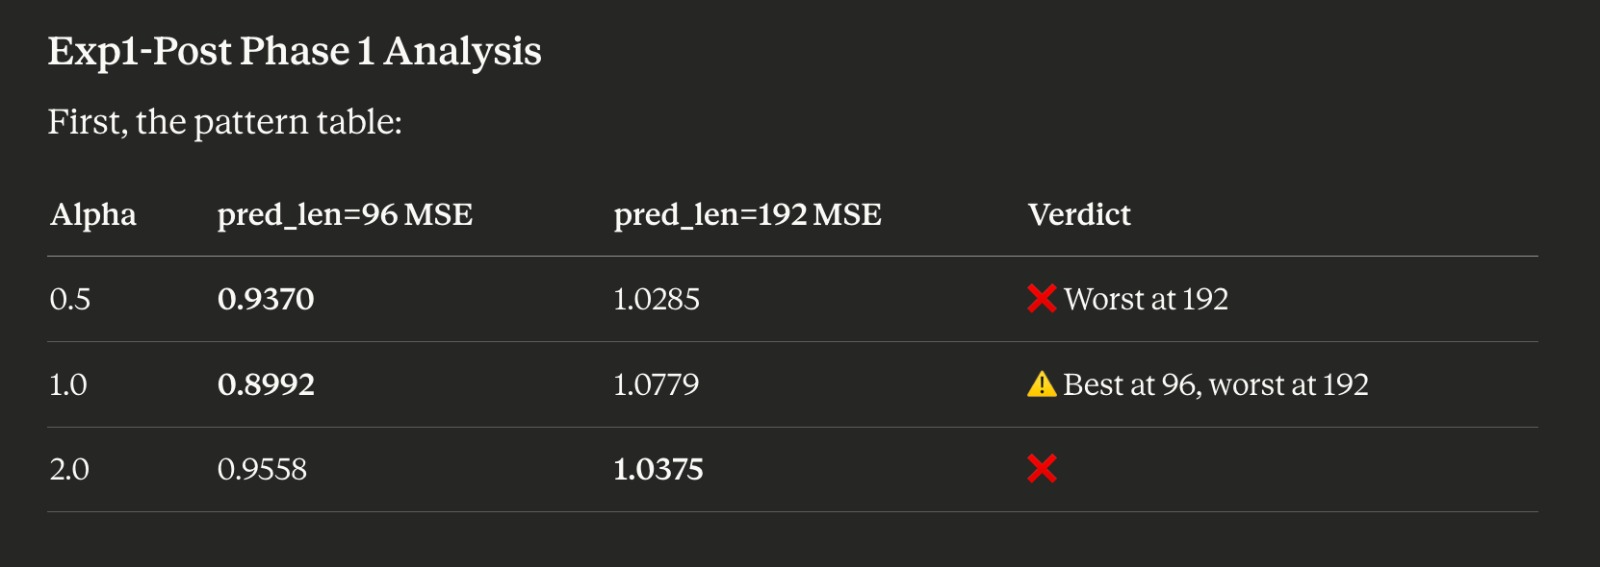

The pattern is unstable — no single alpha wins consistently at both horizons. At pred_len=96, alpha=1.0 wins. At pred_len=192, alpha=2.0 wins. The winner flips.

---

### Critical Finding — Post vs Pre Comparison

| Experiment | Alpha | pred_len=96 | pred_len=192 |
|------------|-------|-------------|--------------|
| Pre-Softmax | 1.0 | 0.8683 | 0.8463 |
| Post-Softmax | best | 0.8992 | 1.0375 |

Post-softmax is consistently worse than pre-softmax across all alphas and both horizons. Every single Post MSE is higher than the corresponding Pre MSE. This is a strong, clear signal.

---

### What This Means

Post-softmax decay is fundamentally less effective because it rescales already-normalised attention probabilities — the softmax has already done its competition, and multiplying by decay afterwards just distorts the probability distribution without principled guidance. Pre-softmax decay influences the competition itself, which is more meaningful.

---

### Decision for Phase 2

Even though the pattern is unstable, you still run Phase 2 — but with a different goal. Since no alpha dominates both horizons, you run alpha=1.0 (best at pred_len=96, the most common benchmark horizon) and document the instability as a finding itself.

15 runs, ~55 minutes. The summary at the end automatically prints your Exp1-Pre Phase 2 numbers alongside the new Post results for direct row-by-row comparison.
The main thing to watch when results come in — if Post is worse than Pre at every pred_len across all 3 seeds, that's a very clean result for your ablation. It directly answers the research question: placement of decay relative to softmax matters, and pre-softmax is the right place.

**PHASE 2**

In [7]:
!bash experiments/exp1_distance_post_softmax/exp1_post_phase2.sh

Exp1-Post  |  PHASE 2 — VALIDATION
Components:   D only (alpha after softmax)
Alpha:        1.0 (best at pred_len=96)
Dataset:      ETTh1
Seeds:        2021, 2022, 2023
Pred lengths: 48, 96, 192, 336
Total runs:   12 (1 alpha × 3 seeds × 4 pred)
Phase 1 note: NO stable alpha winner
              Post-softmax worse than Pre at all alphas
Start time:   Sun Apr  5 10:09:12 AM UTC 2026
Files copied.

---------------------------------------------
RUN:        exp1post_ph2_ETTh1_alpha1.0_pred48_seed2021
Alpha:      1.0 (fixed)
Seed:       2021
Pred len:   48
Start:      Sun Apr  5 10:09:13 AM UTC 2026
---------------------------------------------
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=48, enc_in=7, dec_in=7, c_out=7, d_model=512, n_heads=8, e_layers=2, d_layers=1, s_layers=[3, 2, 1], d_ff=2048, factor=5, padding=0, distil=

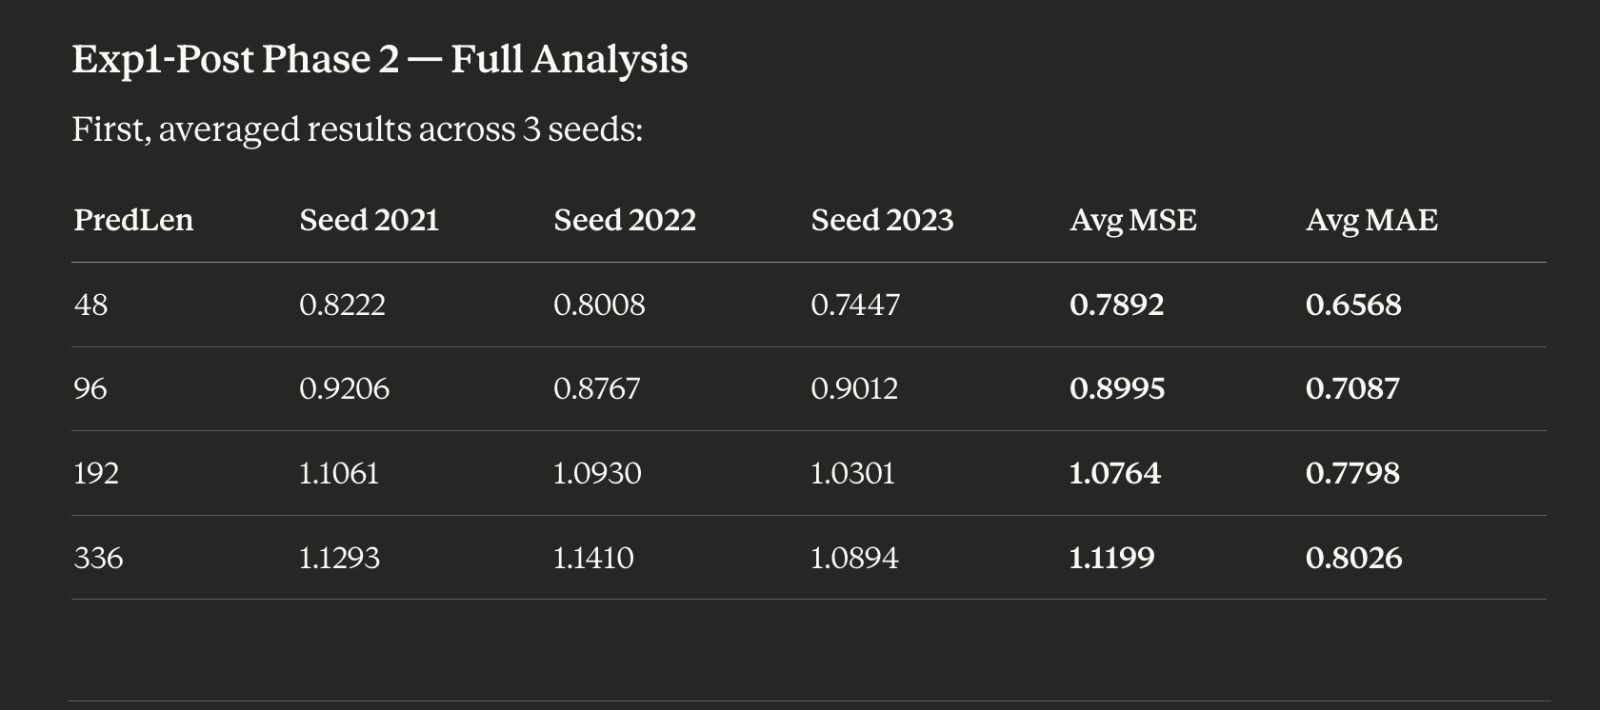

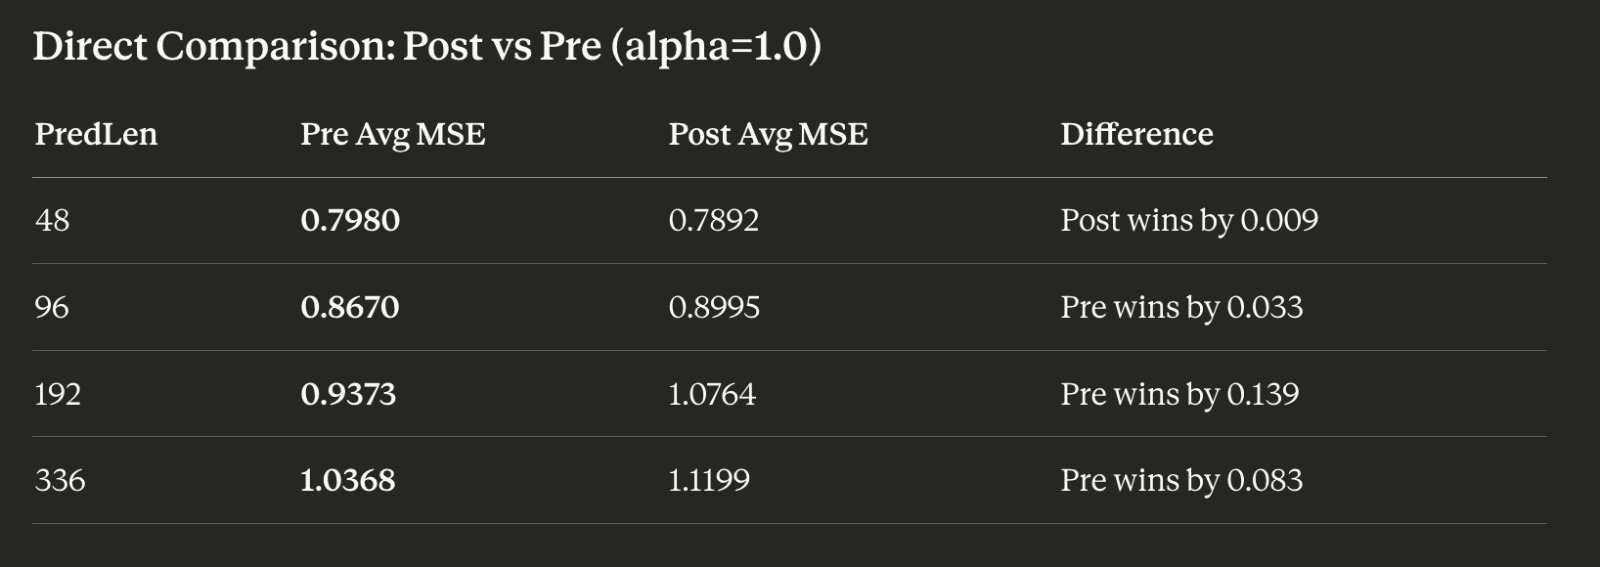

What This Tells You
Pre-softmax wins overall and the gap grows with horizon. At pred_len=48 post-softmax is marginally better (0.009 difference — essentially noise). But from pred_len=96 onwards, pre-softmax is clearly and consistently better, with the gap widening at pred_len=192.
Post-softmax degrades badly at longer horizons. MSE jumps from 0.8995 at pred_len=96 to 1.0764 at pred_len=192 — a 0.18 increase. Pre-softmax only went from 0.8670 to 0.9373 — a 0.07 increase. Post-softmax is twice as sensitive to horizon length.

Exp1-Post Conclusion to Document

Post-softmax distance decay with alpha=1.0 performs comparably to pre-softmax only at very short horizons (pred_len=48), but degrades significantly at mid-to-long horizons (pred_len=96–336). The performance gap between pre and post widens with prediction length, suggesting that applying decay after softmax distorts already-normalised attention probabilities without meaningful benefit. Pre-softmax placement is the superior design choice as it influences the attention competition itself rather than rescaling its output. Exp1-Pre with alpha=1.0 is the recommended configuration from Experiment 1.